# Plotting script for selected ocean variables
this plotting script is for Australian region only


In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask_jobqueue import PBSCluster
from dask.distributed import Client

In [6]:
import dask
# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

client = Client() # Client(threads_per_worker=1) # why?
client


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38713 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38713/status,
Dashboard: /proxy/38713/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35641,Workers: 0
Dashboard: /proxy/38713/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33725,Total threads: 4
Dashboard: /proxy/46275/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:34143,


In [7]:
def load_and_mean(file_path, var):
    """
    Load a dataset from a NetCDF file and compute the mean for a specified variable.
    
    Parameters:
        file_path (str): Path to the NetCDF file containing the dataset.
        var (str): Name of the variable in the dataset for which the mean is to be computed.
        
    Returns:
        mean_data (xarray.DataArray): The mean values of the specified variable.
    """
    ds = xr.open_dataset(file_path)
    tmp1 = ds[var]
    mean_data=tmp1.where(tmp1 != 0)
    return mean_data #, ds['xt_ocean'], ds['yt_ocean']

# List of periods and variables
periods = ['GW1p2', 'GW1p5', 'GW2p0', 'GW3p0', 'GW4p0']
base_period = 'GW1p2'


# Load datasets and compute means
means = {}
coords = {}
#data = means[(var, period)]
#vmin = np.nanmin(data.values)
#vmax = np.nanmax(data.values)


##  My plotting script

In [8]:
## %%time
def all_plot(variable, title, base_period,lev1,lev2,scale):
#    variable='duration'
    min_lat=-45; max_lat=-5
    min_lon=100; max_lon=160
    odir='/g/data/xv83/rxm599/acs/hazard_ocean/paper1/aus_'

    print(variable )
    print(periods)
    fig, axes = plt.subplots(5, 2, figsize=(22, 24), 
            subplot_kw={'projection': ccrs.PlateCarree(central_longitude=140)}, 
            gridspec_kw={'hspace': 0.2, 'wspace': 0.0})
#            gridspec_kw={'hspace': 0.4, 'wspace': 0.3})
    fig.suptitle(title, fontsize=18, y=0.92, weight='bold')

    data_ref1=means[(variable, base_period)]*scale
    if variable == 'OAR' or variable == 'PH' :
        data_ref2=data_ref1.sel(YT_OCEAN=slice(min_lat,max_lat),XT_OCEAN=slice(min_lon,max_lon))
        data_ref=data_ref2.rename({'YT_OCEAN':'yt_ocean','XT_OCEAN':'xt_ocean'})
    elif variable == 'bmf' :
        data_ref2=data_ref1.sel(yu_ocean=slice(min_lat,max_lat),xu_ocean=slice(min_lon,max_lon))
        data_ref=data_ref2.rename({'yu_ocean':'yt_ocean','xu_ocean':'xt_ocean'})
    else:
        data_ref=data_ref1.sel(yt_ocean=slice(min_lat,max_lat),xt_ocean=slice(min_lon,max_lon))
    
    for i, period in enumerate(periods):
        print(period) 
        ax = axes[i, 0]
        data1=means[variable,period]*scale
        if variable == 'OAR' or variable == 'PH' :
            data2=data1.sel(YT_OCEAN=slice(min_lat,max_lat),XT_OCEAN=slice(min_lon,max_lon))
            data=data2.rename({'YT_OCEAN':'yt_ocean','XT_OCEAN':'xt_ocean'})
        elif variable == 'bmf' :
            data2=data1.sel(yu_ocean=slice(min_lat,max_lat),xu_ocean=slice(min_lon,max_lon))
            data=data2.rename({'yu_ocean':'yt_ocean','xu_ocean':'xt_ocean'})
        else:
            data=data1.sel(yt_ocean=slice(min_lat,max_lat),xt_ocean=slice(min_lon,max_lon))

        atmp=area_average(data)
        print('mean', variable,atmp.values  )
        image=data.plot(ax=ax,cmap=plt.cm.plasma,transform=ccrs.PlateCarree(),
           levels=lev1, add_colorbar=False )
        if variable == 'OAR' :  
# for surface OA            
#           data[0,:,:].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
# for bottom OA 
           data.plot.contour(ax=ax,transform=ccrs.PlateCarree(),
           levels=[1], add_colorbar=False, colors='black' )
            
        ax.set_title(f'{period} (Mean)', fontsize=14)
        ax.set_xlabel(' ') #Longitude East')
        ax.set_ylabel(' ') #Latitude')
        ax.coastlines()
        ax.set_xticks(np.arange(min_lon, max_lon+1, 10), crs=ccrs.PlateCarree())  
        ax.set_xticklabels(['100°E','110°E', '120°E', '130°E', '140°E', '150°E', '160°E'])
        ax.set_yticks(np.arange(min_lat, max_lat+1, 10), crs=ccrs.PlateCarree())
        ax.set_yticklabels(['45°S', '35°S', '25°S', '15°S', '5°S'])
        cbar = fig.colorbar( image, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
        cbar.set_label(title)
# second column
        if period != base_period:
            ax = axes[i, 1]
            diff_data = data - data_ref
            image=diff_data.plot(ax=ax,cmap=plt.cm.RdBu_r,transform=ccrs.PlateCarree(),
               levels=lev2, add_colorbar=False )
            ax.set_title(f'{period} (Difference)', fontsize=14)
            ax.coastlines()
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticks(np.arange(min_lon, max_lon+1, 10), crs=ccrs.PlateCarree())  
            ax.set_xticklabels(['100°E','110°E', '120°E', '130°E', '140°E', '150°E', '160°E'])
            ax.set_yticks(np.arange(min_lat, max_lat+1, 10), crs=ccrs.PlateCarree())
            ax.set_yticklabels(['45°S', '35°S', '25°S', '15°S', '5°S'])
            cbar = fig.colorbar( image, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
            cbar.set_label(f'{title} Change')
    
    # Remove the unused subplot in the first row, second column
    fig.delaxes(axes[0, 1])

    plt.savefig(odir+f'{title}.png')
    plt.show()

def get_data(file_template,variables,periods,mean,astr):
# Load datasets and compute means
    means = {}
    coords = {}
    for period in periods:
        for var in variables:
            file_path = file_template.format(period=period)
#            mean_data, lon, lat = load_and_mean(file_path, var)
            mean_data = load_and_mean(file_path, var)
            if mean == True: 
                means[(var, period)] = mean_data.mean(astr)
            else :
                means[(var, period)] = mean_data
#            coords[(var, period)] = (lon, lat)
    return means,coords

def area_average(data):
    weights = np.cos(np.deg2rad(data.yt_ocean))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    data_weighted
    weighted_mean = data_weighted.mean(("xt_ocean", "yt_ocean"))
    return weighted_mean
    

duration
['GW1p2', 'GW1p5', 'GW2p0', 'GW3p0', 'GW4p0']
GW1p2
mean duration 34.29198776702689
GW1p5
mean duration 35.03951968348404
GW2p0
mean duration 301.362796386025
GW3p0
mean duration 366.2219922212579
GW4p0
mean duration 366.24998896826844


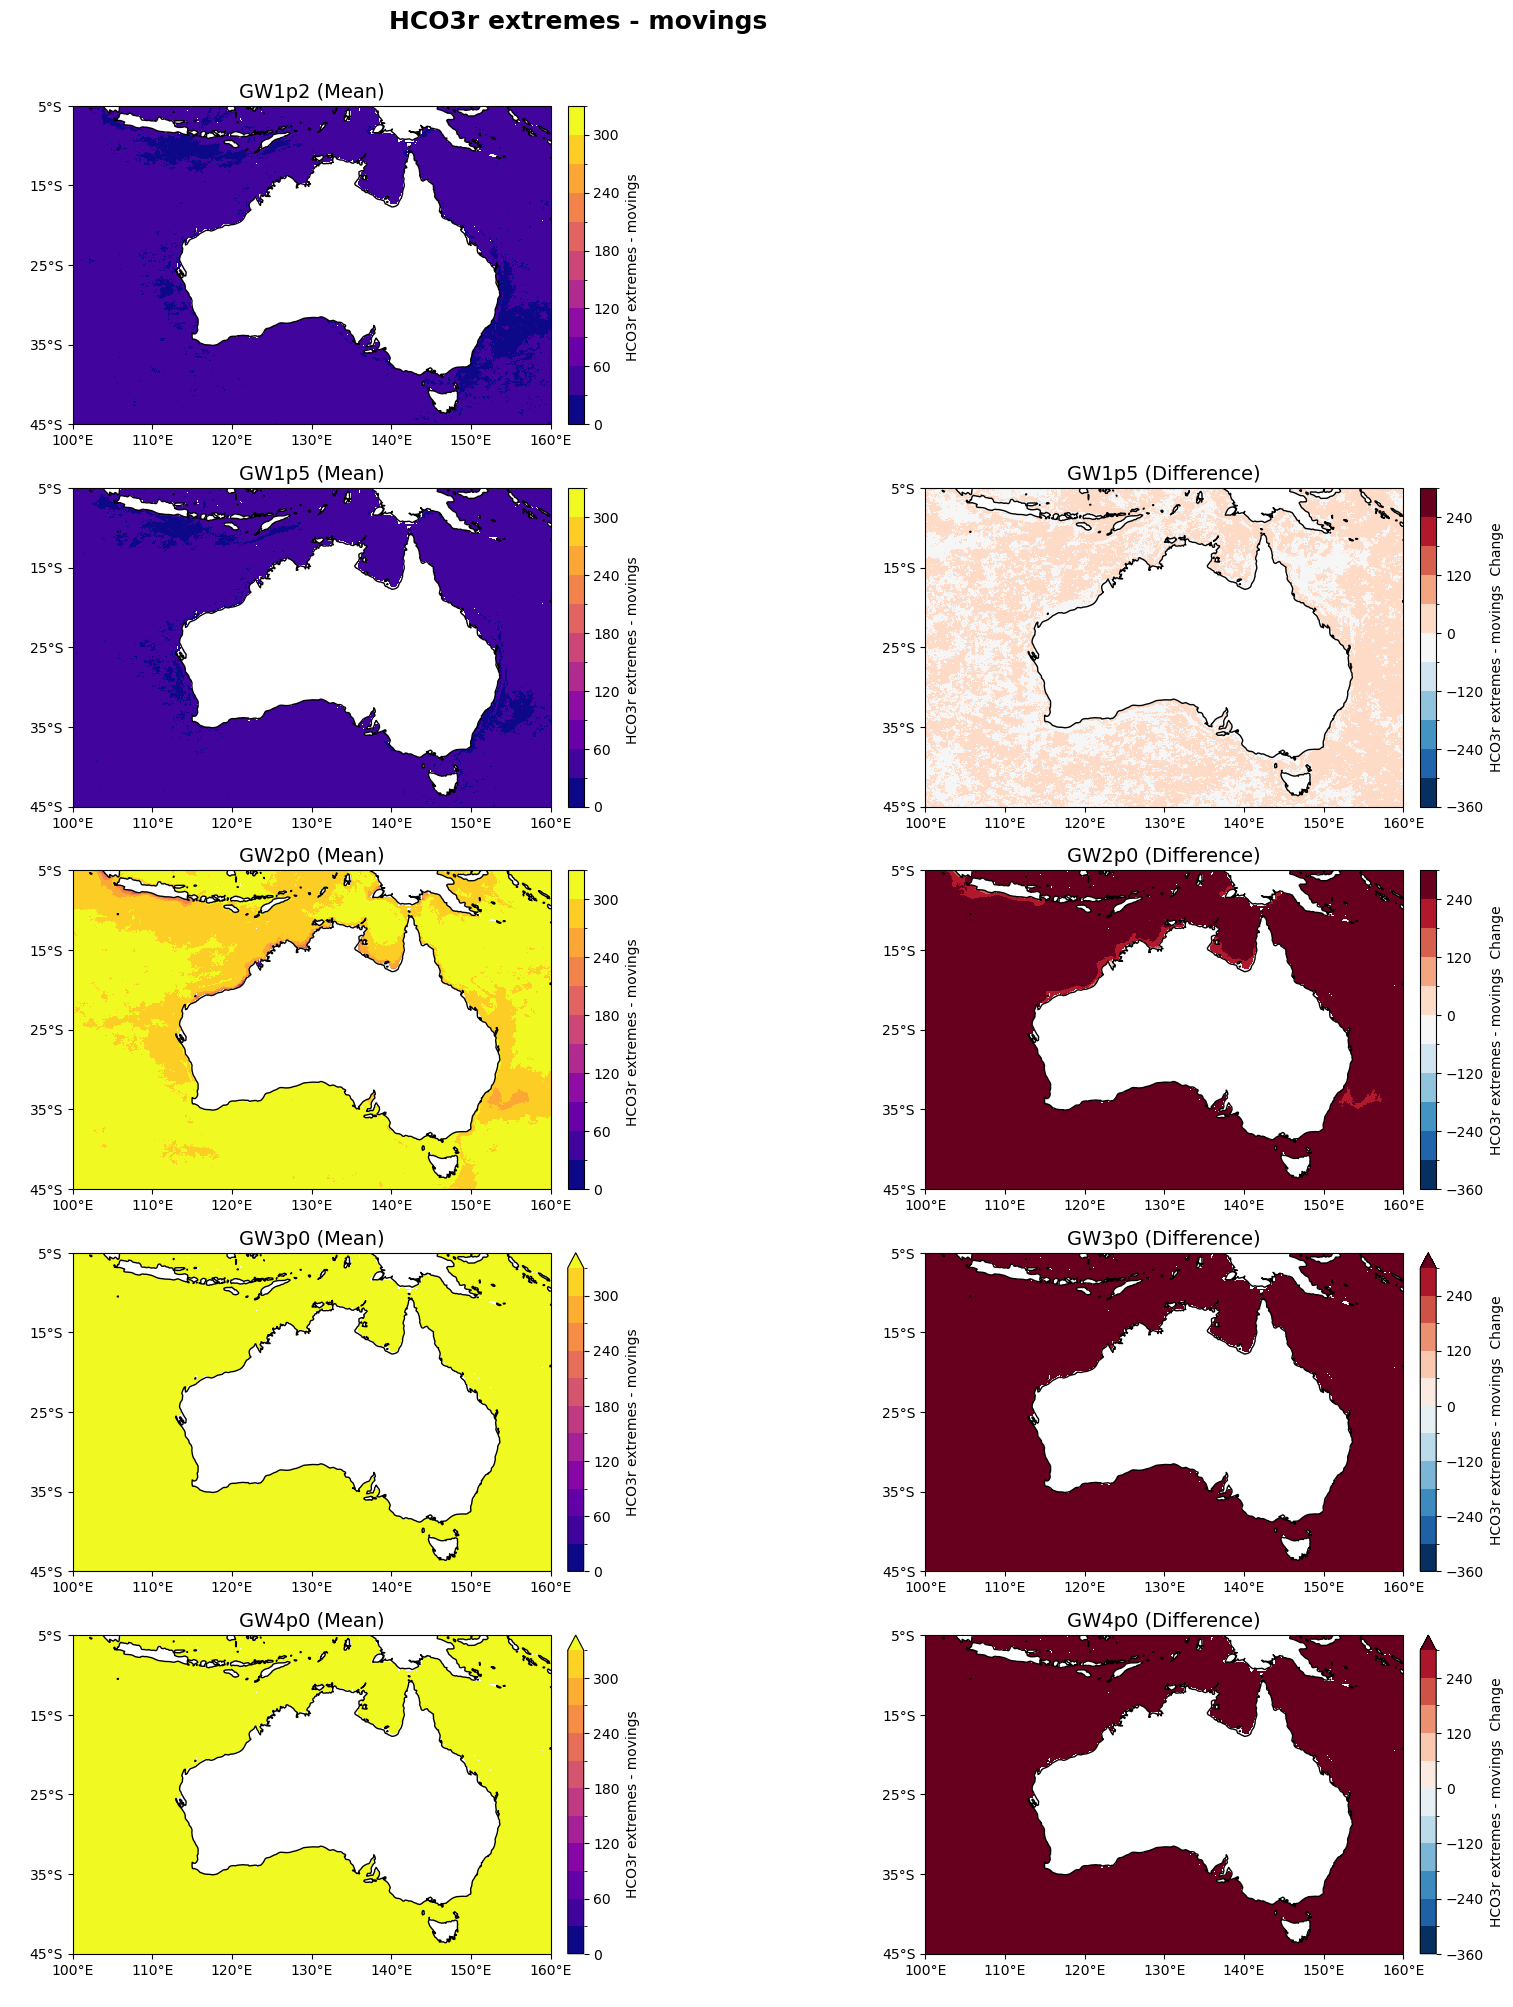

CPU times: user 10.4 s, sys: 1.77 s, total: 12.2 s
Wall time: 10.5 s


In [10]:
%%time
# Template for the file paths
file_template = "/g/data/ia39/ncra/ocean/hco3r_{period}_oax1.nc"
variables = ['duration']

means,coords=get_data(file_template,variables,periods,False,'year')
means['duration','GW1p2']

a1=np.arange(0,360,30)
a2=np.arange(-360,360,60)
lev1=np.concatenate([a1])
lev2=a2
all_plot('duration','HCO3r extremes - movings ',base_period,lev1,lev2,1)

duration
['GW1p2', 'GW1p5', 'GW2p0', 'GW3p0', 'GW4p0']
GW1p2
mean duration 34.85283001490012
GW1p5
mean duration 282.51061129331634
GW2p0
mean duration 366.1362617706471
GW3p0
mean duration 366.2487038032092
GW4p0
mean duration 366.2500000000002


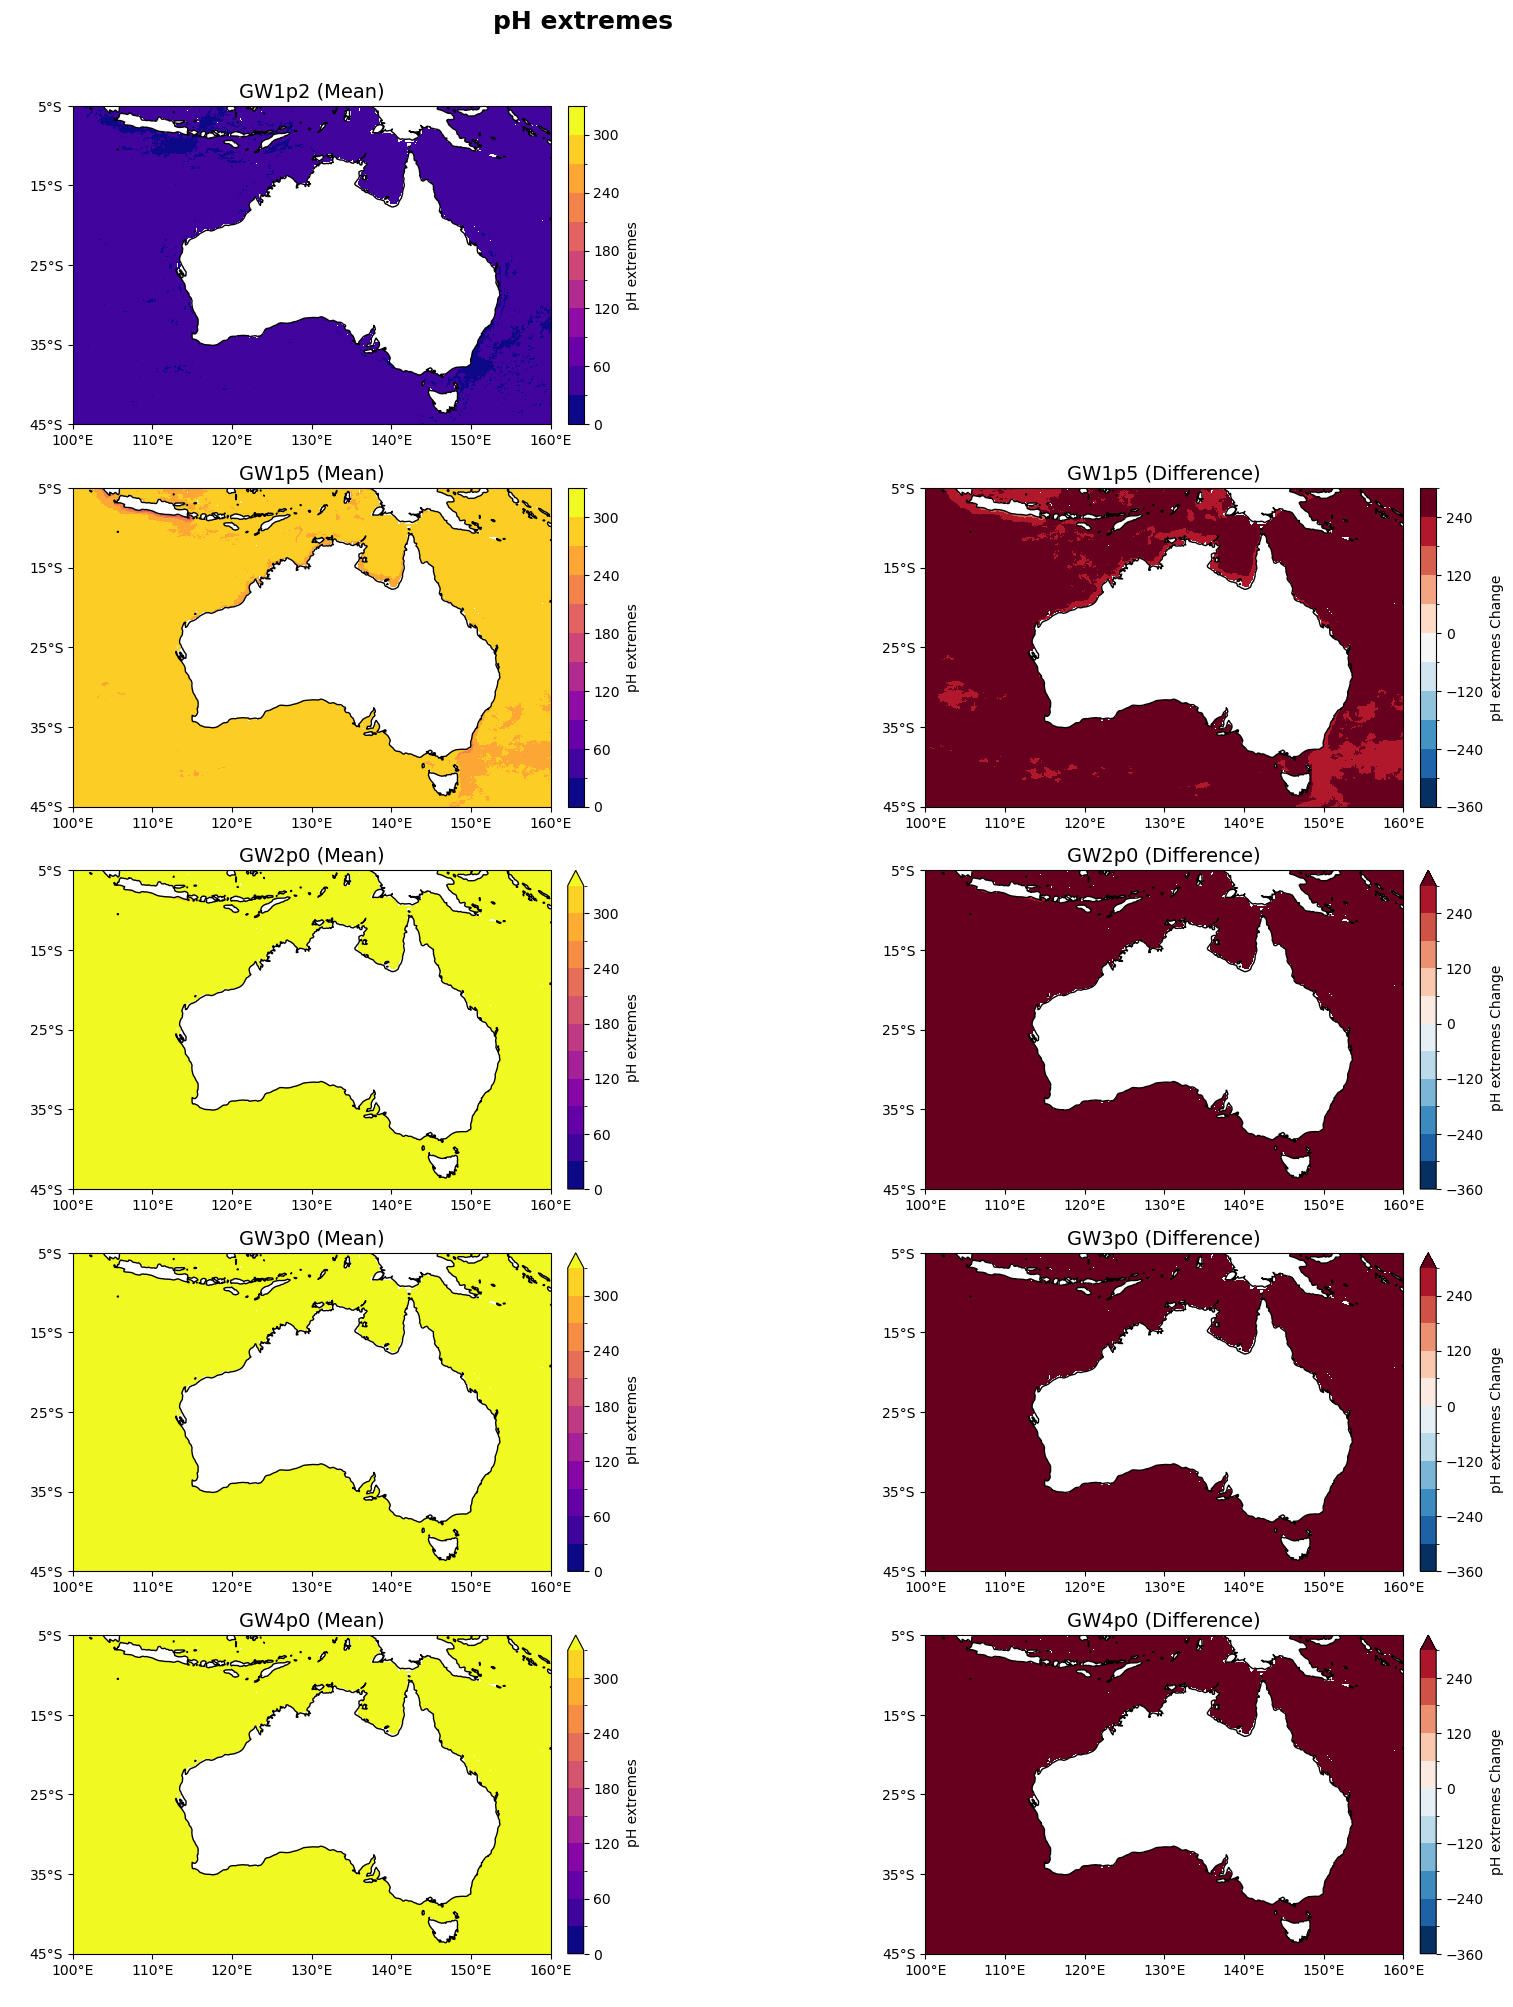

CPU times: user 8.62 s, sys: 1.01 s, total: 9.63 s
Wall time: 9.7 s


In [10]:
%%time
# Template for the file paths
file_template = "/g/data/ia39/ncra/ocean/PHx_{period}.nc"
variables = ['duration']

means,coords=get_data(file_template,variables,periods,False,'year')
means['duration','GW1p2']

a1=np.arange(0,360,30)
a2=np.arange(-360,360,60)
lev1=np.concatenate([a1])
lev2=a2
all_plot('duration','pH extremes',base_period,lev1,lev2,1)

duration
['GW1p2', 'GW1p5', 'GW2p0', 'GW3p0', 'GW4p0']
GW1p2
mean duration 35.3398231193946
GW1p5
mean duration 258.4136533699542
GW2p0
mean duration 362.1454342802436
GW3p0
mean duration 366.2143131495945
GW4p0
mean duration 366.23895528952033


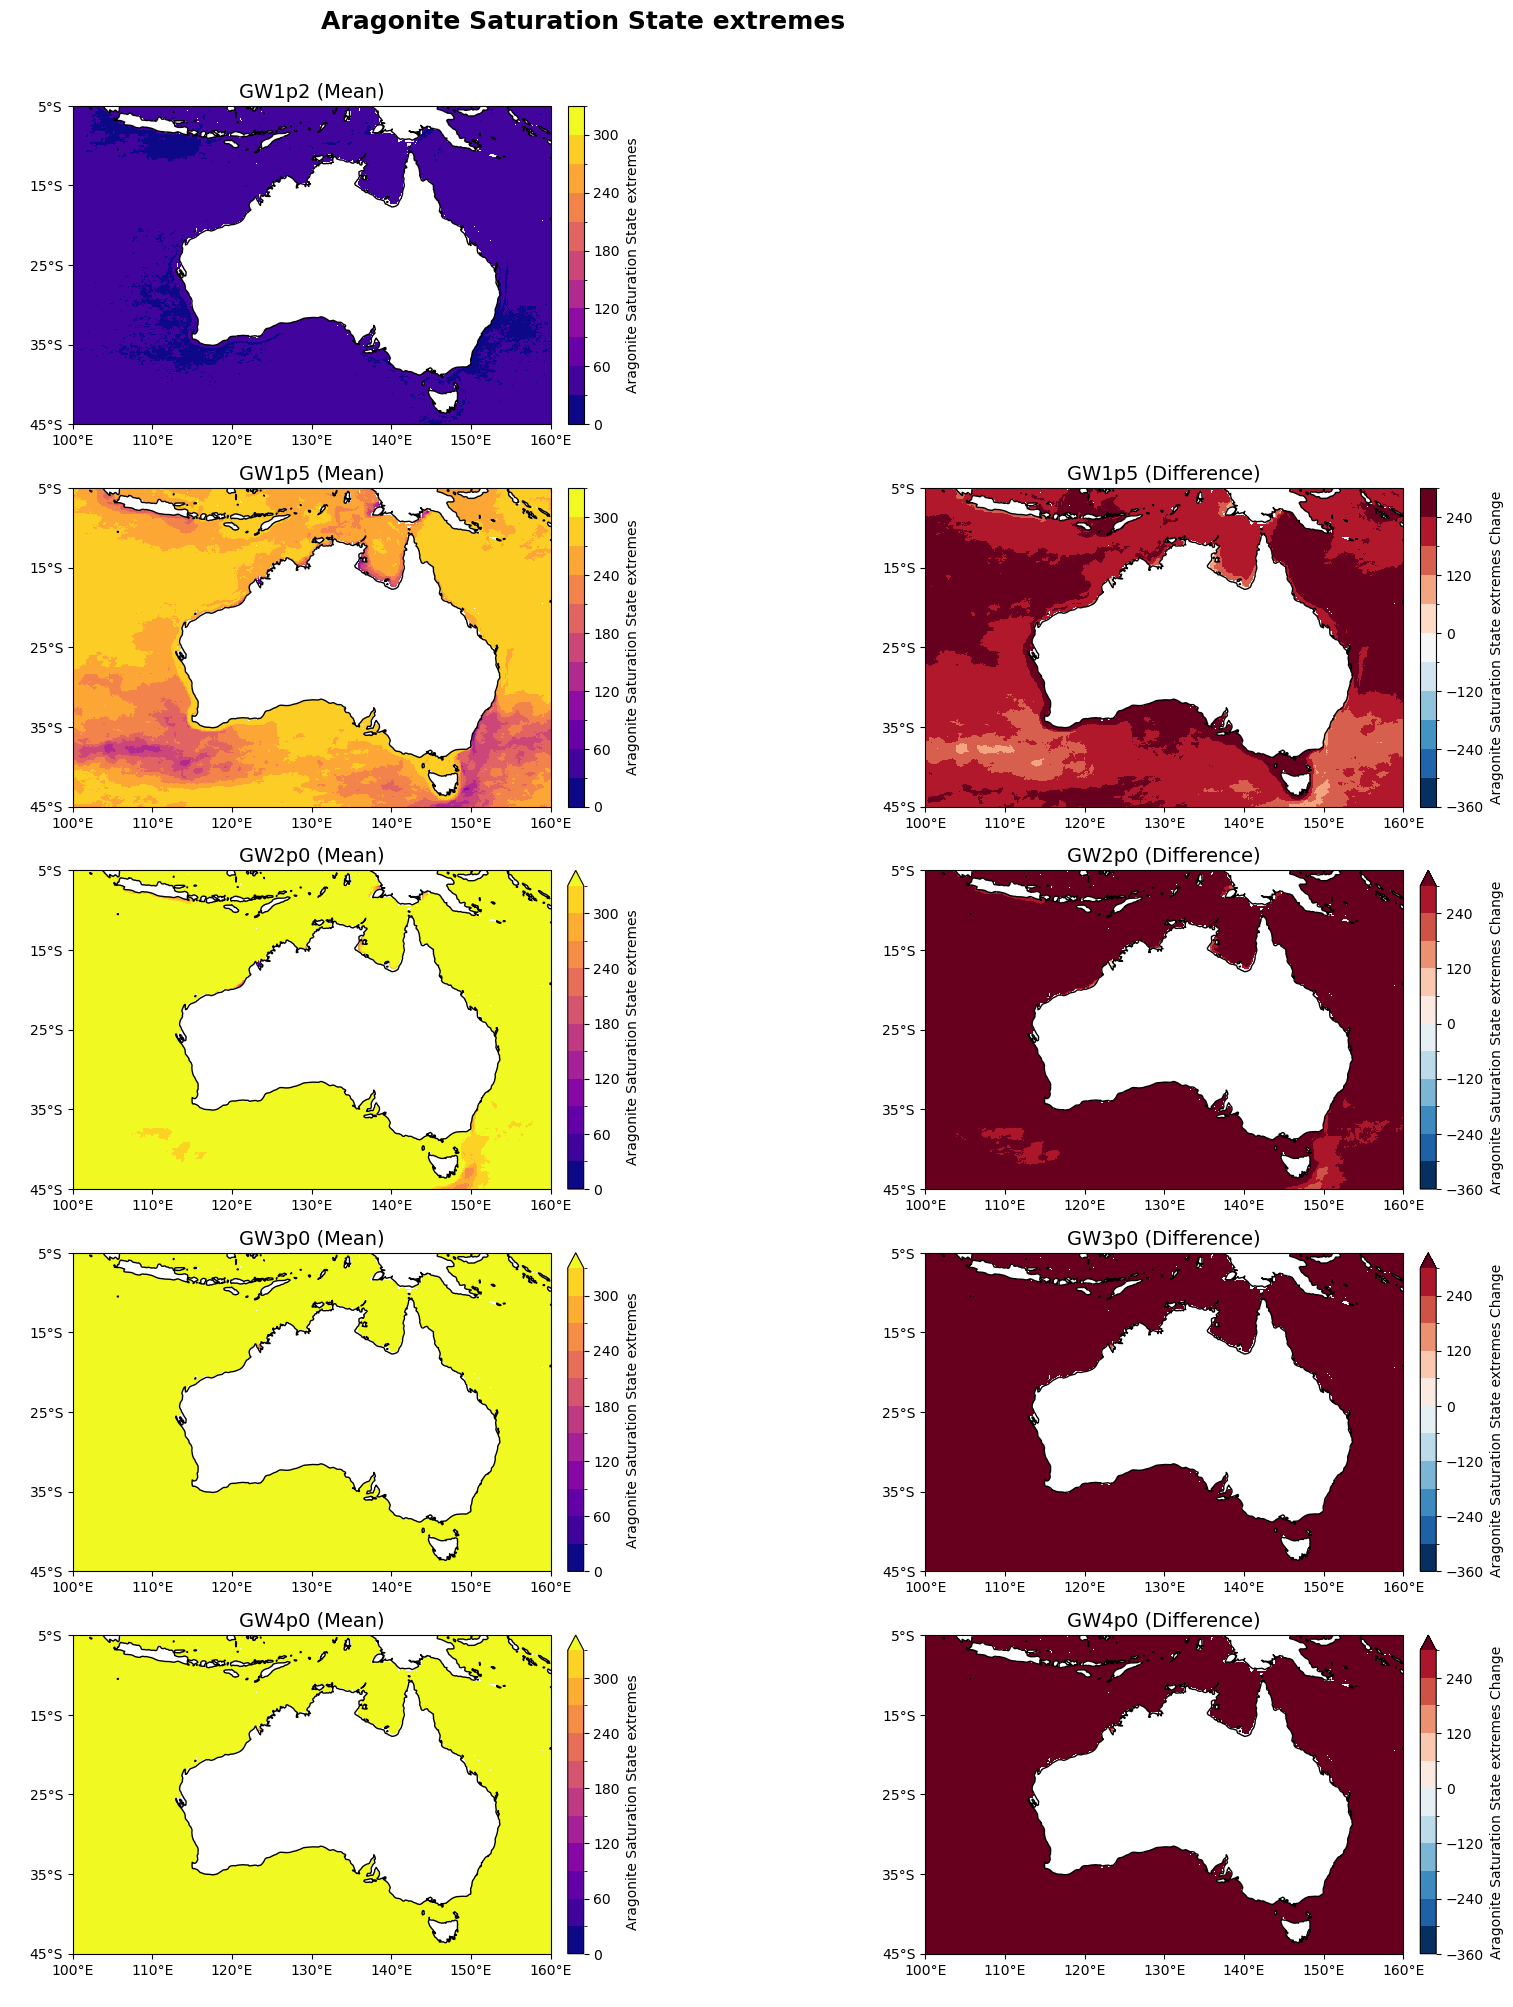

CPU times: user 8.38 s, sys: 1 s, total: 9.38 s
Wall time: 9.53 s


In [11]:
%%time
# Template for the file paths
file_template = "/g/data/ia39/ncra/ocean/OARx_{period}.nc"
variables = ['duration']

means,coords=get_data(file_template,variables,periods,False,'year')
means['duration','GW1p2']

a1=np.arange(0,360,30)
a2=np.arange(-360,360,60)
lev1=np.concatenate([a1])
lev2=a2
all_plot('duration','Aragonite Saturation State extremes',base_period,lev1,lev2,1)

## End

In [ ]:
client.close()